# Summer '26
## Author: Zane Collins
## Last Updated: 06/17/2026


# Imports

In [2]:
from hapi import *

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import pickle

from scipy.signal import correlate


# imp
os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/')
from bin_spec import bin_spectrum
from exo_spec_simv2 import *
from exo_spec_simv2 import run_cross_correlation
os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks')
%matplotlib widget

In [27]:
os.getcwd()

'/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks'

# Parsing

In [28]:
data_dir = '../data'

In [4]:
db_begin("HAPI_DB");

Using HAPI_DB

CH4
                     Lines parsed: 9009
CH4_iso2
                     Lines parsed: 79200
H2O_iso3
                     Lines parsed: 10441
H2O_iso1
                     Lines parsed: 53108
CH4_iso1
                     Lines parsed: 194110
H2O
                     Lines parsed: 15602
H2O_iso2
                     Lines parsed: 14038


In [5]:
tableList()

dict_keys(['sampletab', 'CH4', 'CH4_iso2', 'H2O_iso3', 'H2O_iso1', 'CH4_iso1', 'H2O', 'H2O_iso2'])

In [6]:
wn_min = 4000
wn_max = 7100


## CH4 & Water Fetching

In [7]:
# Isotopes to download:
ch4_isotopes = [1,2]
h2o_isotopes = [1,2,3]

In [8]:
# for isotope in ch4_isotopes:
#     fetch(f"CH4_iso{isotope}", 6, isotope, wn_min, wn_max)
# for isotope in h2o_isotopes:
#     fetch(f"H2O_iso{isotope}", 1, isotope, wn_min, wn_max)

# Helper Functions

In [9]:
def compute_transmission(molecule, isotope, dwn, T = 288, p = 1, column_density = 1e12, path_length = 1e5,scale_factor = 1.0):

    #Check if the molecule and isotope are in the database
    table_name = f"{molecule}_iso{isotope}"
    # if table_name not in [t[0] for t in tableList()]:
    #     raise ValueError(f"{molecule} with isotope {isotope} not found in database. Table {table_name}")
    
    #Fetch the absorption coefficients for the specified molecule and isotope
    wn_grid, coef = absorptionCoefficient_Voigt(
            Components=[(6, isotope, 1)],
            SourceTables=table_name,
            WavenumberRange=(wn_min, wn_max),
            WavenumberStep=dwn,
            Environment={'T': T, 'p': p} 
        )
    
    # Calculate the transmission using the Beer-Lambert law
    tau = coef * column_density * path_length

    tau *= scale_factor

    transmission = np.exp(-tau)

    wavelength_grid = 1e4 / wn_grid
    wavelength_grid
    resolution = np.median(wn_grid) / dwn

    return wavelength_grid, transmission, resolution

def generate_res_isotope_dict(molecules, isotopes_dict, dwns, 
                              T=288, p=1, column_density=1e12, 
                              path_length=1e5, scale_factor=1.0):
    """
    Generate nested dictionary: resolution -> molecule -> isotope -> data
    """
    res_dict = {}   # Main dictionary: res_key -> mol -> iso -> data
    
    for dwn in dwns:
        for mol in molecules:
            isotopes = isotopes_dict.get(mol, [])
            
            for iso in isotopes:
                # Compute the spectrum
                wl, trans, resolution = compute_transmission(
                    mol, iso, dwn, T, p, column_density, path_length, scale_factor
                )
                
                # Use clean integer key for resolution
                res_key = int(round(resolution))
                
                # Initialize nested structure if needed
                if res_key not in res_dict:
                    res_dict[res_key] = {}
                if mol not in res_dict[res_key]:
                    res_dict[res_key][mol] = {}
                
                # Store the data
                res_dict[res_key][mol][iso] = {
                    'wavelength_grid': wl,
                    'transmission': trans,
                    'resolution': resolution,      # keep float if you want
                    'dwn': dwn
                }
                
                print(f"Added: R={res_key} | {mol} iso{iso} | dwn={dwn}")
    
    return res_dict
        
def create_combined_transmission(data_dict, molecule_abundances, res, T=None, p=None, scale_factor=None):
    """
    molecule_abundances: dict[molecule] = dict[isotope] = fractional abundance (or column density scaling)
    Example: {'CH4': {1: 0.8, 2: 0.2}, 'H2O': {1: 1.0}}
    """
    tau_total = None
    wl_grid = None
    
    for mol, iso_abunds in molecule_abundances.items():
        for iso, frac in iso_abunds.items():
            # print(f'data_dict[{res}][{mol}][{iso}]')
            try:
                data = data_dict[res][mol][iso]
                current_wl = data['wavelength_grid']
                trans = data['transmission']
            except KeyError:
                print(f"Missing data for {mol} iso {iso} at res {res}")
                continue
                
            if wl_grid is None:
                wl_grid = current_wl
            
            tau = -np.log(np.clip(trans, 1e-10, 1.0))  # avoid log(0), tau = -ln(T) = -ln(exp(-tau)) = tau
            tau_total = tau * frac if tau_total is None else tau_total + tau * frac # Sum the optical depths weighted by their fractional abundances
    
    if tau_total is None:
        raise ValueError("No data found for any species")
    
    combined_trans = np.exp(-tau_total)
    return wl_grid, combined_trans


# Create binned dictionary
def create_binned_versions(parent_dict, R_values):
    """
    Take the high-res parent and bin it to multiple target resolutions.
    """
    binned_dict = {}   # resolution -> molecule -> isotope -> data
    
    for res_key in parent_dict.keys():           # usually just one fine resolution
        for mol in parent_dict[res_key].keys():
            for iso in parent_dict[res_key][mol].keys():
                data = parent_dict[res_key][mol][iso]
                wl_fine = data['wavelength_grid']
                trans_fine = data['transmission']
                
                for R in R_values:

                    # Ensure ascending wavelength order (critical for SpectRes)
                    sort_idx = np.argsort(wl_fine)
                    wl_fine = wl_fine[sort_idx]
                    trans_fine = trans_fine[sort_idx]

                    
                    wl_binned, trans_binned, _ = bin_spectrum(
                        wl_fine, trans_fine, R
                    )
                    
                    if R not in binned_dict:
                        binned_dict[R] = {}
                    if mol not in binned_dict[R]:
                        binned_dict[R][mol] = {}
                    
                    binned_dict[R][mol][iso] = {
                        'wavelength_grid': wl_binned,
                        'transmission': trans_binned,
                        'resolution': R,
                        'parent_resolution': res_key
                    }
                    
                    print(f"Binned {mol} iso{iso} to R = {R:,}")
    
    return binned_dict


# Noise injection
def inject_poisson_noise(data, SNR):

    signal = np.average(data)  # Representative signal level for scaling noise
    print(f"Average signal level: {signal:.4e}")
    scale = signal / SNR if signal > 0 else 1.0 
    print(f"scale factor: {scale:.4e} for SNR={SNR}")

    poisson_noise = np.random.poisson(lam=data)
    poisson_noise = poisson_noise - data  # Center the noise around zero
    
    noisy_data = data + poisson_noise * scale / np.sqrt(signal)  # Scale noise by SNR and signal level
    noisy_data = np.clip(noisy_data, 0, None)  # Ensure non-negative values

    errorbars = np.sqrt(data) * scale / np.sqrt(signal)  # Poisson noise error bars

    return noisy_data, errorbars

def inject_gaussian_noise(data, SNR, seed = 8):

    depth = 1.0 - data          # or np.abs(1.0 - data) if baseline isn't exactly 1
    signal_level = np.max(depth)   # Peak depth
    # signal_level = np.sqrt(np.mean(depth**2))   # RMS depth
    
    sigma = signal_level / SNR
    # print(f"Signal level: {signal_level:.4e}, Noise std dev: {sigma:.4e} for SNR={SNR}")

    nchan = len(data)
    rng = np.random.default_rng(seed)

    random_pertubations = sigma*rng.standard_normal(nchan)
    # print(f"Actual noise std: {random_pertubations.std():.4e} | Max |noise|: {np.abs(random_pertubations).max():.4e}")

    


    synthetic_atmosphere = data + random_pertubations 
    synthetic_atmosphere = np.clip(synthetic_atmosphere, 0, None) 
    
    errorbars = np.full_like(data, sigma) 
    return synthetic_atmosphere, errorbars



# Test

In [10]:
# dwns = [0.1,1]
# ch4_isos = [1,2]
# h2o_isos = [1]

# data_dict = generate_res_isotope_dict(['CH4','H2O'], ch4_isos, dwns, T=288, p=1, column_density=1e12, path_length=1e5, scale_factor=5.0)

In [11]:
# test_molecule_abundances = {'CH4': {1: 1, 2: 1}, 'H2O': {1: 10.0}}
# wl_grid, combined_trans = create_combined_transmission(data_dict, test_molecule_abundances, dwn=0.1, T=288, p=1)

In [12]:
# print(data_dict['CH4'][0.1][1][2])

In [13]:
# plt.figure(figsize=(10, 6))
# plt.plot(wl_grid, combined_trans, label='Combined Transmission')
# plt.plot(data_dict['CH4'][0.1][1][0], data_dict['CH4'][0.1][1][1], label='CH4 iso 1')
# plt.plot(data_dict['CH4'][0.1][2][0], data_dict['CH4'][0.1][2][1], label='CH4 iso 2')
# plt.plot(data_dict['H2O'][0.1][1][0], data_dict['H2O'][0.1][1][1], label='H2O iso 1')
# plt.xlabel('Wavelength (nm)')
# plt.ylabel('Transmission')
# plt.title('Combined Transmission Spectrum')
# plt.legend()
# plt.grid()

In [14]:
# noisy_combined = {}

# snr_values = [1,5, 10, 50, 100, 1000]

# for snr in snr_values:
#     key = f"SNR_{snr}"
#     noisy_combined[key] = {}
    
#     # Generate noise per SNR
#     noisy_trans, error_bars = inject_gaussian_noise(combined_trans, snr)
    
#     noisy_combined[key]['Transmission'] = noisy_trans
#     noisy_combined[key]['ErrorBars']    = error_bars          
#     noisy_combined[key]['wl_grid']      = wl_grid.copy() 

# Cross Correlation Tests

## Generating Data

#### Create hi-res parent spectra

In [ ]:
parent_dwn = 0.001
molecules = ['CH4', 'H2O']
isotopes_dict = {'CH4': [1, 2]}


In [ ]:
# # 1. Compute the high-resolution parent spectrum once

# parent_dict = generate_res_isotope_dict(
#     molecules=molecules,
#     isotopes_dict=isotopes_dict,
#     dwns=[parent_dwn],           # only one fine grid
#     scale_factor=5.0
# )
# # parent_dict now has one key (e.g. 555000) with the fine data

# # Save the data

# save_path = os.path.join(data_dir, f"parent_spectra_dwn({parent_dwn})_mol({molecules}).pkl")

# with open(save_path, 'wb') as f:
#     pickle.dump(parent_dict, f)

# print(f"✅ Saved parent_dict to: {save_path}")


{'air': 1.0}
100.219882 seconds elapsed for abscoef; nlines = 194110
Added: R=5550000 | CH4 iso1 | dwn=0.001
{'air': 1.0}
29.443830 seconds elapsed for abscoef; nlines = 79200
Added: R=5550000 | CH4 iso2 | dwn=0.001


In [ ]:
load_path = os.path.join(data_dir, f"parent_spectra_dwn({parent_dwn})_mol({molecules}).pkl")

with open(load_path, 'rb') as f:
    parent_dict = pickle.load(f)

print(f"✅ Loaded parent_dict with resolutions: {list(parent_dict.keys())}")

✅ Saved parent_dict to: ../data/parent_spectra_dwn(0.001)_mol(['CH4', 'H2O']).pkl


In [16]:
resolutions = [100, 500,1000,5000, 10000, 5e4, 1e5]
data_dict = create_binned_versions(parent_dict, resolutions)

Binned CH4 iso1 to R = 100
Binned CH4 iso1 to R = 500
Binned CH4 iso1 to R = 1,000
Binned CH4 iso1 to R = 5,000
Binned CH4 iso1 to R = 10,000
Binned CH4 iso1 to R = 50,000.0
Binned CH4 iso1 to R = 100,000.0
Binned CH4 iso2 to R = 100
Binned CH4 iso2 to R = 500
Binned CH4 iso2 to R = 1,000
Binned CH4 iso2 to R = 5,000
Binned CH4 iso2 to R = 10,000
Binned CH4 iso2 to R = 50,000.0
Binned CH4 iso2 to R = 100,000.0


In [17]:
# plt.figure(figsize=(10,6))
# for r in resolutions:
#     plt.plot(data_dict[r]['CH4'][1]['wavelength_grid'], data_dict[r]['CH4'][1]['transmission'], label = f'Resolution: {r}')

# plt.legend()
# plt.grid()
# plt.show()

In [35]:
#Generate combined spectra for tracea bundances
trace_ch4_molecule_abundances = {'CH4': {1: 0.95, 2: 1e-4}}
combined_dict_trace_ch4 = {}

for res in resolutions:
    combined_dict_trace_ch4[res] = {}
    wl_grid, combined_trans = create_combined_transmission(data_dict, trace_ch4_molecule_abundances, res = res, T=288, p=1)
    combined_dict_trace_ch4[res]['wl_grid'] = wl_grid
    combined_dict_trace_ch4[res]['combined_trans'] = combined_trans

# Generate combined spectra for even abundances

even_ch4_molecule_abundances = {'CH4': {1: 0.5, 2: .5}}
combined_dict_even_ch4 = {}

for res in resolutions:
    combined_dict_even_ch4[res] = {}
    wl_grid, combined_trans = create_combined_transmission(data_dict, trace_ch4_molecule_abundances, res = res, T=288, p=1)
    combined_dict_even_ch4[res]['wl_grid'] = wl_grid
    combined_dict_even_ch4[res]['combined_trans'] = combined_trans

# generate combined spectra for earth-like abundances
earth_ch4_molecule_abundances = {'CH4': {1: 0.5, 2: .01}}
combined_dict_earth_ch4 = {}

for res in resolutions:
    combined_dict_earth_ch4[res] = {}
    wl_grid, combined_trans = create_combined_transmission(data_dict, trace_ch4_molecule_abundances, res = res, T=288, p=1)
    combined_dict_earth_ch4[res]['wl_grid'] = wl_grid
    combined_dict_earth_ch4[res]['combined_trans'] = combined_trans


In [19]:
# r_to_plot = 1000

# plt.figure(figsize=(10,6))
# #plot combined
# plt.plot(combined_dict[r_to_plot]['wl_grid'], combined_dict[r_to_plot]['combined_trans'], label = f'combined_trans: {r_to_plot}')

# #Plot isotopes
# plt.plot(data_dict[r_to_plot]['CH4'][1]['wavelength_grid'], data_dict[r_to_plot]['CH4'][1]['transmission'], label = f'Isotope 1, Resolution: {r_to_plot}', alpha = 0.6)
# plt.plot(data_dict[r_to_plot]['CH4'][2]['wavelength_grid'], data_dict[r_to_plot]['CH4'][2]['transmission'], label = f'Isotope 2, Resolution: {r_to_plot}', alpha = 0.6)

# plt.legend()
# plt.grid()
# plt.show()


### Noisify

In [36]:
noisy_combined = {}

snr_values = [1,5, 10, 50, 100, 500]

for res in resolutions:
    noisy_combined[res] = {}
    for snr in snr_values:
        key = f"SNR_{snr}"
        noisy_combined[res][key] = {}
        combined_trans= combined_dict_trace_ch4[res]['combined_trans']
        wl_grid = combined_dict_trace_ch4[res]['wl_grid']
        
        # Generate noise per SNR
        noisy_trans, error_bars = inject_gaussian_noise(combined_trans, snr)    
        noisy_combined[res][key]['Transmission'] = noisy_trans
        noisy_combined[res][key]['ErrorBars']    = error_bars          
        noisy_combined[res][key]['wl_grid']      = wl_grid.copy()

## Cross-Correlating

In [ ]:
results_pure = run_cross_correlation(
    # data_dict=combined_dict
    data_dict=data_dict, 
    noisy_combined=noisy_combined, 
    molecule='CH4', 
    isotope=2,
    # combined_template = False
);

results_earth_isos = run_cross_correlation(
    data_dict=combined_dict_earth_ch4,
    noisy_combined=noisy_combined, 
    molecule='CH4', 
    isotope=2,
    combined_template = True
)


Cross-correlating using template: CH4 (isotope 2)

  → R = 100 | SNR_1 | max_corr = 0.2606 | CC-SNR = 3.36
  → R = 100 | SNR_5 | max_corr = 0.7189 | CC-SNR = 8.48
  → R = 100 | SNR_10 | max_corr = 0.8913 | CC-SNR = 13.94
  → R = 100 | SNR_50 | max_corr = 0.9836 | CC-SNR = 21.77
  → R = 100 | SNR_100 | max_corr = 0.9874 | CC-SNR = 22.44
  → R = 100 | SNR_500 | max_corr = 0.9889 | CC-SNR = 22.78
  → R = 500 | SNR_1 | max_corr = 0.1480 | CC-SNR = 4.08
  → R = 500 | SNR_5 | max_corr = 0.4561 | CC-SNR = 12.48
  → R = 500 | SNR_10 | max_corr = 0.6705 | CC-SNR = 18.57
  → R = 500 | SNR_50 | max_corr = 0.8516 | CC-SNR = 24.86
  → R = 500 | SNR_100 | max_corr = 0.8609 | CC-SNR = 25.36
  → R = 500 | SNR_500 | max_corr = 0.8644 | CC-SNR = 25.65
  → R = 1,000 | SNR_1 | max_corr = 0.1223 | CC-SNR = 7.32
  → R = 1,000 | SNR_5 | max_corr = 0.2597 | CC-SNR = 10.33
  → R = 1,000 | SNR_10 | max_corr = 0.4714 | CC-SNR = 17.92
  → R = 1,000 | SNR_50 | max_corr = 0.7790 | CC-SNR = 26.92
  → R = 1,000 | SNR

## Plotting Spectra

In [39]:
snr_to_plot = 10
dwn_to_plot = 10
isotope_to_plot = 2

In [40]:
# fig, ax = plt.subplots(figsize=(10, 6))
# plt.plot(data_dict['CH4'][dwn_to_plot][isotope_to_plot][0], data_dict['CH4'][dwn_to_plot][isotope_to_plot][1], label=f'CH4 iso {isotope_to_plot} (dwn={dwn_to_plot})', color='blue')
# plt.plot(noisy_combined[dwn_to_plot][f'SNR_{snr_to_plot}']['wl_grid'], noisy_combined[dwn_to_plot][f'SNR_{snr_to_plot}']['Transmission'], label=f'Noisy Combined (SNR={snr_to_plot})', color='orange', alpha = 0.7)
# plt.xlabel('Wavelength (nm)')
# plt.ylabel('Transmission')
# plt.title(f'CH4 iso {isotope_to_plot} and Noisy Combined Transmission (dwn={dwn_to_plot}, SNR={snr_to_plot})')
# plt.legend()
# plt.grid()

## Plotting Results

In [41]:
# df['resolution'] = pd.to_numeric(df['resolution'], errors='coerce')

# # Sort by resolution for clean lines
# df = df.sort_values(by='resolution')

# # Plot
# plt.figure(figsize=(10, 6))

# for snr_label in df['snr'].unique():
#     subset = df[df['snr'] == snr_label]
#     plt.plot(subset['resolution'], subset['cc_snr'], 
#              marker='o', label=snr_label)

# plt.xscale('log')                    # usually better for resolution
# plt.xlabel('Spectral Resolution (R)')
# plt.ylabel('Cross-Correlation SNR (Cross-Correlation Value / Std Dev of Correlation)')
# plt.title('CC SNR vs Spectral Resolution for different SNR levels')
# plt.legend(title='Input SNR')
# plt.grid(True, which='both', ls='--', alpha=0.7)


# plt.tight_layout()
# plt.show()

In [42]:
# plt.figure(figsize=(10, 6))
# for snr_label in df['snr'].unique():
#     subset = df[df['snr'] == snr_label]
#     plt.plot(subset['resolution'], subset['max_correlation'], 
#              marker='o', label=snr_label)

# plt.xscale('log')                    # usually better for resolution
# plt.xlabel('Spectral Resolution (R)')
# plt.ylabel('Max Cross-Correlation')
# plt.title('Max Cross-Correlation vs Spectral Resolution for different SNR levels')
# plt.legend(title='Input SNR')
# plt.grid(True, which='both', ls='--', alpha=0.7)

In [51]:
df_earth = pd.DataFrame(results_earth_isos)
df_pure = pd.DataFrame(results_pure)

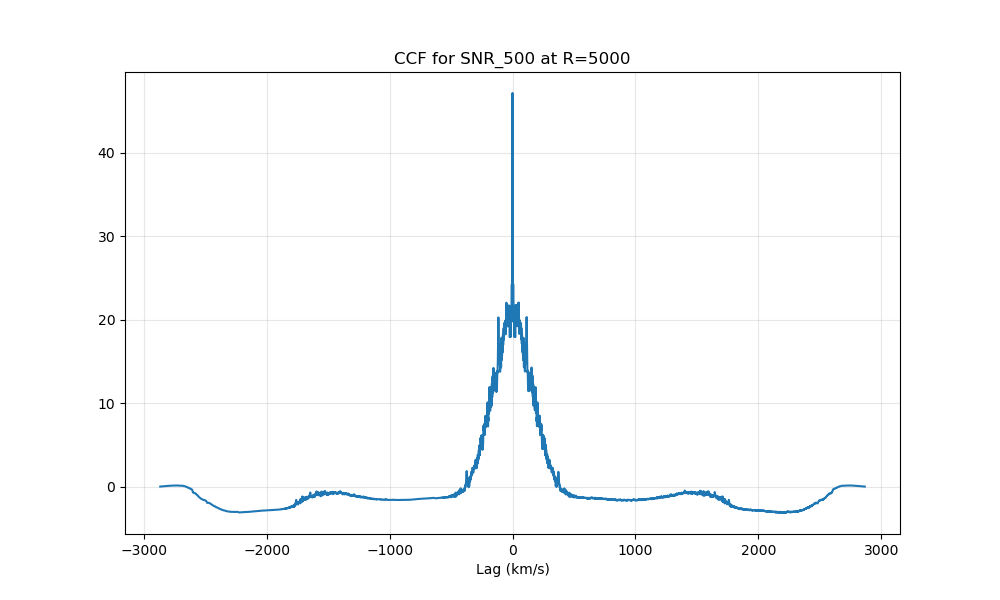

In [48]:
snr_to_plot = 'SNR_500'
res_to_plot = 5000
cc_value = False
# Filter the dataframe
subset = df_earth[(df_earth['snr'] == snr_to_plot) & (df_earth['resolution'] == res_to_plot)]

if len(subset) == 0:
    print("No matching data!")
else:
    row = subset.iloc[0] #only row
    
    lags = np.array(row['lags'])
    if cc_value:
        y = np.array(row['ccf'])
        plt.ylabel('Cross-Correlation')

    else:
        y = np.array(row['cc_snr'])
        plt.ylabel('CC SNR')
    plt.figure(figsize=(10, 6))
    plt.plot(lags, y)
    plt.xlabel('Lag (km/s)')
    plt.title(f'CCF for {snr_to_plot} at R={res_to_plot}')
    plt.grid(True, alpha=0.3)
    plt.show()

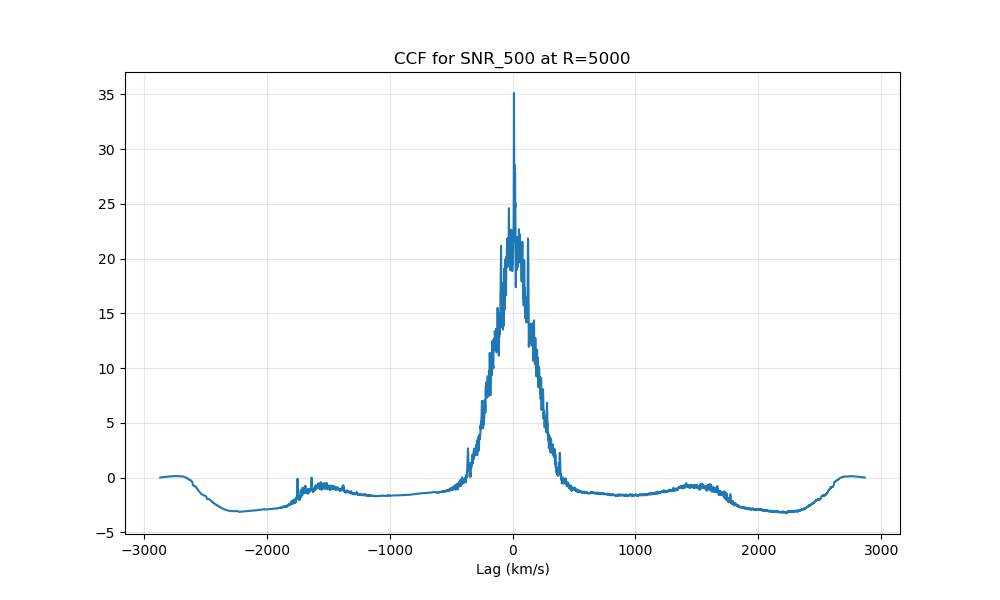

In [52]:
snr_to_plot = 'SNR_500'
res_to_plot = 5000
cc_value = False
# Filter the dataframe
subset = df_pure[(df_pure['snr'] == snr_to_plot) & (df_pure['resolution'] == res_to_plot)]

if len(subset) == 0:
    print("No matching data!")
else:
    row = subset.iloc[0] #only row
    
    lags = np.array(row['lags'])
    if cc_value:
        y = np.array(row['ccf'])
        plt.ylabel('Cross-Correlation')

    else:
        y = np.array(row['cc_snr'])
        plt.ylabel('CC SNR')
    plt.figure(figsize=(10, 6))
    plt.plot(lags, y)
    plt.xlabel('Lag (km/s)')
    plt.title(f'CCF for {snr_to_plot} at R={res_to_plot}')
    plt.grid(True, alpha=0.3)
    plt.show()